# CREDIT LOAN RISK DATA ANALYSIS

Credits to Lao Tse for the dataset.
You can access the dataset [here](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)

### Data Analysis and Exploration

In this part of the notebook, the cleaned data are examined and analyzed for to answer the questions stated on the previous notebook. The hypothesis of the questions are formed based on the exploration of data conducted in this notebook. With hypothesis, the following questions are:

* What is the overall default rate in our dataset?
  * *Ho*: The default rate is less than 20%.
* How does the DTI (Debt to Income) ratio correlate with the likelihood of defaulted loans? 
  * *Ho*: The higher the DTI, the more loans are defaulted. 
* Which combination of age, income, loan intent, loan amount, loan grade, and home ownership has the highest chance of defaulting?
  *  *Ho*: The younger, less income, debt consolidation, higher amount, lower grade and renting borrowers are mosty likely to default.
* What is the average loan amount requested per age group?
  *  *Ho*: 18 - 35 average around $30,000, 36-50 average around $50,0000, while 51 to 65 are around $100,000
* Do borrower with longer credit history borrow more money?
  *  *Ho*: Yes, the longer the credit history, the more money is borrowed

##### Age

Examining the age of the borrowers can help in analyzing the credit risk of borrowers and how it affects the loan and its attributes. The analyst used the following code to proceed:

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [125]:
person_ages = pd.read_csv('cleaned_data/cleaned_person_ages.csv')
person_ages.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Clean_person_age  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


In [126]:
person_ages.describe()

,Clean_person_age
count,32581.000000
mean,27.719254
std,6.206590
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,94.000000


The code shows the statistical summary of the cleaned data. Grouping the ages into subsets can provide more insights such as how much of the age groups occupy most of the data. This can be done using the following:

In [127]:
age_young_group = person_ages[(person_ages >= 18) & (person_ages <= 25)] # Get all ages between 18 and 25
age_middle_group = person_ages[(person_ages >= 26) & (person_ages <= 40)] # Get all ages between 26 and 40
age_old_group = person_ages[(person_ages >= 41) & (person_ages <= 55)] # Get all ages between 41 and 55
age_pre_retire_group = person_ages[(person_ages >= 56) & (person_ages <= 65)] # Get all ages between 56 and 65
age_retire_group = person_ages[person_ages >= 66] # Get all ages 66 and above

# Store the count of each subgroup into a dataframe
age_groups = pd.DataFrame([
  age_young_group.count(), 
  age_middle_group.count(),
  age_old_group.count(),
  age_pre_retire_group.count(),
  age_retire_group.count()
  ], index=['18-25','26-40','41-55','56-65','66+']
)
age_groups = age_groups.rename(columns={'Clean_person_age':'Count'}) # Change column name
age_groups


,Count
18-25,15354
26-40,15735
41-55,1358
56-65,104
66+,30


Text(0.5, 1.0, 'Age Groups and Number of borrowers.')

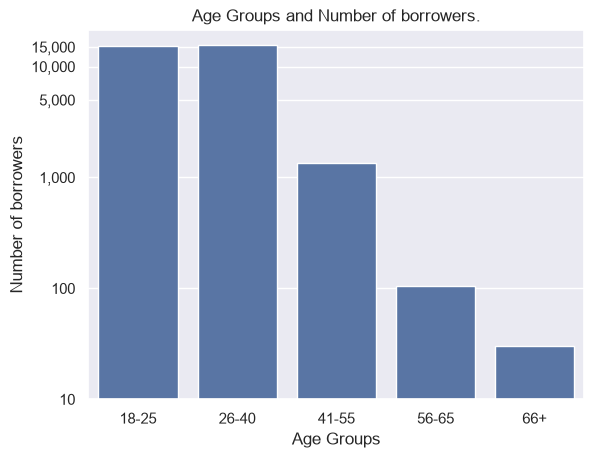

In [128]:
sb.set_theme() # Set color theme
chart = sb.barplot(data=age_groups, x=age_groups.index, y='Count') # Plot the data with x as the age groups and y as the count
chart.set_yscale('log', base=10) # Scale the y-axis as log base of 10
chart.set_yticks([10, 100, 1000, 5000, 10000,15000])  # Display these specific ticks
chart.set_yticklabels(['10', '100', '1,000', '5,000', '10,000','15,000']) # Set the labels
chart.yaxis.set_minor_formatter(plt.NullFormatter()) # Show only the needed tick labels

chart.set_xlabel('Age Groups') # x label
chart.set_ylabel('Number of borrowers') # y label
chart.set_title('Age Groups and Number of borrowers.') # title

The results show the number of borrowers divided into separate subgroups. The group of `26-40` ranks the most with the highest number of borrowers followed by `18-25`, then `41-55`, then `56-65` then finally, `66+`. Compared to `18-25` and `26-40`, the gap between them ranges immensely, from `15,354` to `1,358`, `1034`, and `38`. This shows that majority of the borrowers have the ages `18-40`. Basically diving the ages into two groups. To demonstrate the differences, the following pie chart will show the difference:

Text(0.5, 1.0, 'Two Groups of Borrowers By Ages')

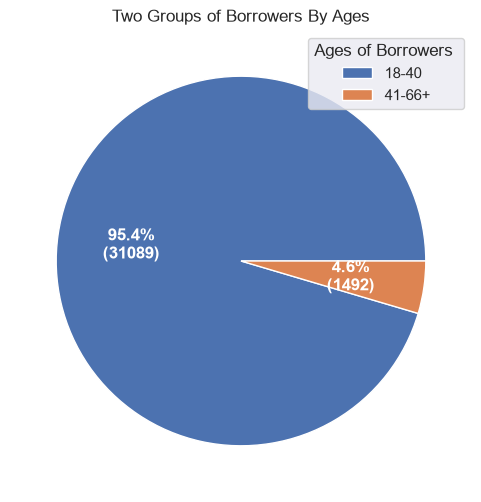

In [129]:
first_group = age_young_group.count() + age_middle_group.count() # Get first group
second_group = age_old_group.count() + age_pre_retire_group.count() + age_retire_group.count() # Get second group
groups = pd.DataFrame([first_group, second_group]) # store as dataframe

fig, ax = plt.subplots(figsize=(6,6)) # Create one subplot
pie = ax.pie(groups['Clean_person_age']) # Make piechart of the column

# Set pie chart labels
ax.pie_label(pie, '{frac:.1%}\n({absval:d})', 
              textprops=dict(color='w', size=12, weight='bold')
              )

# Set pie chart legends
ax.legend(pie.wedges,['18-40','41-66+'],
            title='Ages of Borrowers '
           )

# Set pie chart title
ax.set_title('Two Groups of Borrowers By Ages')

##### Income

Income is very important as it is the main way a loan can be paid. For loaners, this is the basis on how long a loan will last and the basis for the DTI. The data can be examined further using the following:

In [130]:
person_incomes = pd.read_csv('cleaned_data/cleaned_person_incomes.csv')
person_incomes.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Clean_person_income  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


In [131]:
person_incomes['Clean_person_income'].describe().apply(lambda x: format(x,'f'))

count      32581.000000
mean       65892.533624
std        52546.222840
min         4000.000000
25%        38500.000000
50%        55000.000000
75%        79200.000000
max      2039784.000000
Name: Clean_person_income, dtype: str

(array([1.e+03, 2.e+03, 5.e+03, 1.e+04, 2.e+04, 5.e+04, 1.e+05, 2.e+05,
        5.e+05, 1.e+06, 2.e+06, 5.e+06]),
 [Text(1000.0, 0, '1,000'),
  Text(2000.0, 0, '2,000'),
  Text(5000.0, 0, '5,000'),
  Text(10000.0, 0, '10,000'),
  Text(20000.0, 0, '20,000'),
  Text(50000.0, 0, '50,000'),
  Text(100000.0, 0, '100,000'),
  Text(200000.0, 0, '200,000'),
  Text(500000.0, 0, '500,000'),
  Text(1000000.0, 0, '1,000,000'),
  Text(2000000.0, 0, '2,000,000'),
  Text(5000000.0, 0, '5,000,000')])

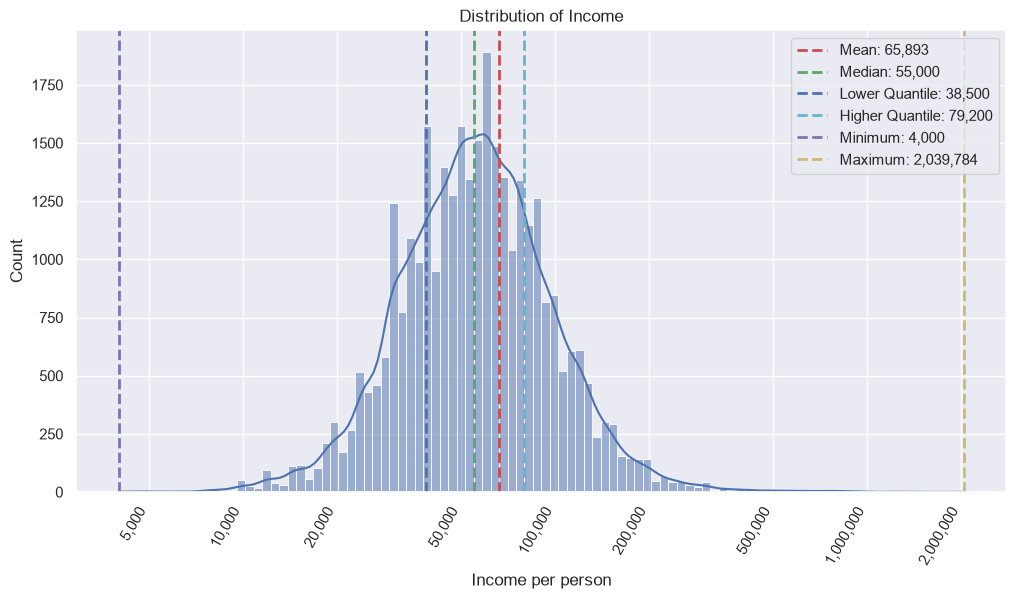

In [ ]:
from matplotlib import scale
from  matplotlib.ticker import LogLocator
from matplotlib.ticker import FuncFormatter

min_val = person_incomes['Clean_person_income'].min()
max_val = person_incomes['Clean_person_income'].max()

mean_val = person_incomes['Clean_person_income'].mean()
median_val = person_incomes['Clean_person_income'].median()
lower_val = person_incomes['Clean_person_income'].quantile(0.25)
higher_val = person_incomes['Clean_person_income'].quantile(0.75)

total = person_incomes['Clean_person_income'].count()

num_bins =  2 * ((higher_val - lower_val) * (total ** 1/3))

plt.figure(figsize=(12,6))
incomes = sb.histplot(person_incomes,
                      x=person_incomes['Clean_person_income'],
                      bins=100, 
                      stat='count',
                      log_scale=True,
                      kde=True,)
incomes.xaxis.set_major_formatter(FuncFormatter(lambda x, _:f'{int(x):,}'))
incomes.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 5]))

incomes.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
incomes.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val:,.0f}')
incomes.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower Quantile: {lower_val:,.0f}')
incomes.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher Quantile: {higher_val:,.0f}')

incomes.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val:,.0f}')
incomes.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val:,.0f}')

incomes.set_xlabel('Income per person')
incomes.set_title('Distribution of Income')
incomes.legend()

plt.xticks(rotation=60, horizontalalignment="right")


The graph shows the distribution of income spikes just between the median and mean values and to the little right of the median. This means that most of the borrower's income are in these range. The minimum and maximum value sets the boundaries of the graph 

In [164]:
person_incomes['Clean_person_income'].skew()

np.float64(9.747678448663162)